### [손글씨 숫자 0 ~ 9 인식 및 분류 모델 학습]

- 데이터 관련
    * 로딩 및 기본 확인 : EDA
    * 전처리 진행
    * 데이터 가공

- 학습 관련
    * 피쳐, 타겟 분리
    * 데이터셋 분리 : 학습|검증|테스트
    * 데이터 가공 -> 데이터 누수 예방
    * 학습/검증/테스트 함수
- 학습 진행
    * 학습 관련 설정값
    * 학습 관련 인스턴스들
    * 학습 진행 + 진행 과정에 대한 로그 : 학습과 검증의 loss, score 등등
- 학습 평가
    * 학습 과정 로그기반 시각화
    * 과대/과소/최적 평가

> [1] 데이터 관련

In [ ]:
import pandas as pd, numpy as np, torch, sys, matplotlib.pyplot as plt, koreanize_matplotlib

sys.path.append('./mnist_classes.py')
sys.path.append('../DAY04/dl_func.py')
from mnist_classes import *
from dl_func import *

from sklearn.model_selection import train_test_split

# 최적화, 손실함수, 데이터로더 관련 모듈
from torch.utils.data import DataLoader
from torch.optim import Adam
from torch.nn import CrossEntropyLoss

In [2]:
train = pd.read_csv('../Data/mnist_train.csv', header=None)
test = pd.read_csv('../Data/mnist_test.csv', header=None)
display(train.head(2))
display(test.head(2))

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
row0 = train.iloc[0]
train_lbl, train_data = row0[0], row0[1:].values.reshape(28,28)
print(train_lbl, train_data.shape)

row0 = test.iloc[0]
test_lbl, test_data = row0[0], row0[1:].values.reshape(28,28)
print(test_lbl, test_data.shape)

5 (28, 28)
7 (28, 28)


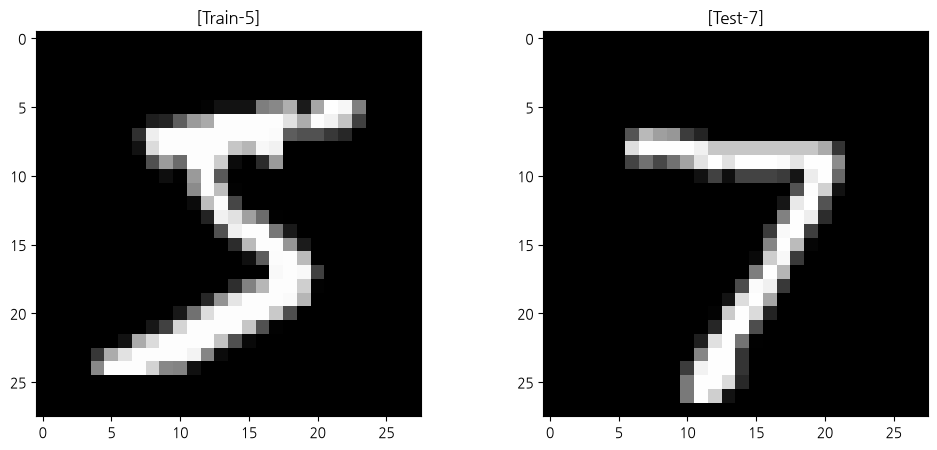

In [4]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

titles = ['Train','Test']
lbl = [train_lbl, test_lbl]
data = [train_data, test_data]

for ax, title, label, img in zip(axes, titles, lbl, data):
    ax.set_title(f'[{title}-{label}]')
    ax.imshow(img, cmap='gray')
plt.show()

In [5]:
feature = train[train.columns[1:]]
target = train[train.columns[0]]
print(feature.shape, target.shape)

feature_test = test[test.columns[1:]]
target_test = test[test.columns[0]]

(60000, 784) (60000,)


In [6]:
# 학습용 : 검증용 = 8 : 2
x_train, x_valid, y_train, y_valid = train_test_split(feature, target,
                                                      test_size=0.2,
                                                      random_state=42,
                                                      stratify=target)
print(x_train.shape, y_train.shape)
print(x_valid.shape, y_valid.shape)

(48000, 784) (48000,)
(12000, 784) (12000,)


In [7]:
# 학습 진행 관련 설정
epochs = 30
bs = 500

# W,B 업데이트/ 값 보정 간격
LR = 0.001

# 학습위치
DIVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
model = MnistCnn().to(DIVICE)

adam = Adam(model.parameters(), lr=LR)
lossFN = CrossEntropyLoss()

trainDL = DataLoader(MnistDataset(x_train, y_train), batch_size=bs, shuffle=True)
validDL = DataLoader(MnistDataset(x_valid, y_valid), batch_size=bs)
testDL = DataLoader(MnistDataset(feature_test, target_test), batch_size=bs)

In [9]:
## 성능지표
from sklearn.metrics import f1_score
import datetime

## 에포크 단위 loss 저장용 변수 
lossEpoch, scoreEpoch = {'Train':[], 'Valid':[]},   {'Train':[], 'Valid':[]}

## -------------------------------
## EarlyStopping 관련 변수
## -> Valid Score가 가장 좋았던 시점의 모델 가중치를 저장해두고
##    그 이후로 patience번 연속 개선이 없으면 학습을 중단
## -------------------------------
best_valid_score = -1
best_epoch = -1
best_model_state = None
patience = 5
no_improve_cnt = 0

## 전체 학습 시작 시각
train_start = datetime.datetime.now()

for epo in range(epochs+1):
    ## 에포크 시작 시각
    epo_start = datetime.datetime.now()

    ## loss, score 저장 변수
    lossDict  = {'Train':[], 'Valid':[]}
    scoreDict = {'Train':[], 'Valid':[]}

    ## -------------------------------
    ## 모델 학습 모드 설정
    ## -------------------------------
    model.train()

    ## 배치 단위 학습 진행
    for data, target in trainDL:
        ## 모델과 동일한 위치로 이동
        data, target = data.to(DIVICE), target.to(DIVICE)

        ## 순전파 진행 => 가중치 합계
        pre_target = model(data)

        ## 역전파 업데이트 위한 grad 초기화 
        ## => 모델의 모든 층의 W,b에 업데이트할 값 저장 속성 grad
        ## => 초기화 하지 않으면 누적 
        adam.zero_grad()

        ## 손실 계산 -> 주의: 손실함수마다 원하는 자료형, 형태가 다름!
        ## -> CrossEntropyLoss : 정답 타겟 - 1D, Long
        loss = lossFN(pre_target, target.reshape(-1).long())

        ## 역전파 진행=> 새로운 W,b 값 계산 후 grad에 저장 
        loss.backward() 

        ## W,b 업데이트 
        adam.step()
    
        ## F1 점수계산 
        preNP   = pre_target.argmax(dim=1).detach().cpu().squeeze().numpy()
        labelNP = target.detach().cpu().squeeze().numpy()
        score   = f1_score(labelNP, preNP, average='macro')

        ## 배치단위 손실 저장
        lossDict['Train'].append(loss.item())
        scoreDict['Train'].append(score)

    # -------------------------------
    # 모델 검증 모드 설정
    # -------------------------------
    ## 역전파, 기울기계산 등 비활성화
    model.eval()

    ## W,b 텐서의 requires_grad=False
    with torch.no_grad():
        for data, target in validDL:
            ## 모델과 동일한 위치로 이동
            data, target = data.to(DIVICE), target.to(DIVICE)

            # 예측
            pre_target = model(data)

            # 손실
            loss = lossFN(pre_target, target.reshape(-1).long())

            # F1 점수
            preNP   = pre_target.argmax(dim=1).detach().cpu().squeeze().numpy()
            labelNP = target.detach().cpu().squeeze().numpy()
            score   = f1_score(labelNP, preNP, average='macro')

            # 손실 및 F1점수 저장 
            lossDict['Valid'].append(loss.item())
            scoreDict['Valid'].append(score)

    ## 에포크 종료 시각 및 소요시간
    epo_elapsed = datetime.datetime.now() - epo_start

    ## 에포크 단위 손실 평균값 저장 및 출력
    if not epo%1:
        for key_name in ['Train', 'Valid']:
            loss  = sum(lossDict[key_name])/len(lossDict[key_name])
            score = sum(scoreDict[key_name])/len(scoreDict[key_name])
            lossEpoch[key_name].append(loss)
            scoreEpoch[key_name].append(score)

        print(f"[EPOCH-{epo:04}] TRAIN LOSS :{lossEpoch['Train'][-1]:.7f}  SCORE :{scoreEpoch['Train'][-1]:.7f}", end=' ')
        print(f"   VALID LOSS :{lossEpoch['Valid'][-1]:.7f}  SCORE :{scoreEpoch['Valid'][-1]:.7f}", end=' ')
        print(f"   TIME :{str(epo_elapsed).split('.')[0]}")

        ## -------------------------------
        ## EarlyStopping 체크 : Valid Score가 개선되면 가중치 저장, 아니면 카운트 증가
        ## -------------------------------
        cur_valid_score = scoreEpoch['Valid'][-1]
        if cur_valid_score > best_valid_score:
            best_valid_score = cur_valid_score
            best_epoch = epo
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve_cnt = 0
        else:
            no_improve_cnt += 1
            if no_improve_cnt >= patience:
                print(f"\n[EarlyStopping] EPOCH-{epo:04}에서 중단 (최고 성능 EPOCH-{best_epoch:04}, VALID SCORE :{best_valid_score:.7f})")
                break

## 전체 학습 종료 시각 및 총 소요시간
train_elapsed = datetime.datetime.now() - train_start
print(f"\n총 학습 소요 시간 : {str(train_elapsed).split('.')[0]}")

## 가장 성능 좋았던 시점의 가중치로 모델 복원
model.load_state_dict(best_model_state)
print(f"최종 모델 : EPOCH-{best_epoch:04} 가중치로 복원 완료 (VALID SCORE :{best_valid_score:.7f})")

[EPOCH-0000] TRAIN LOSS :0.4330494  SCORE :0.8718360    VALID LOSS :0.1617634  SCORE :0.9514636    TIME :0:00:02
[EPOCH-0001] TRAIN LOSS :0.1223612  SCORE :0.9622585    VALID LOSS :0.1266039  SCORE :0.9621562    TIME :0:00:02
[EPOCH-0002] TRAIN LOSS :0.0797211  SCORE :0.9744026    VALID LOSS :0.1069852  SCORE :0.9683801    TIME :0:00:01
[EPOCH-0003] TRAIN LOSS :0.0555282  SCORE :0.9816964    VALID LOSS :0.1020349  SCORE :0.9707392    TIME :0:00:01
[EPOCH-0004] TRAIN LOSS :0.0395174  SCORE :0.9866542    VALID LOSS :0.1138854  SCORE :0.9678850    TIME :0:00:01
[EPOCH-0005] TRAIN LOSS :0.0336796  SCORE :0.9889592    VALID LOSS :0.1077253  SCORE :0.9707163    TIME :0:00:02
[EPOCH-0006] TRAIN LOSS :0.0284211  SCORE :0.9899162    VALID LOSS :0.1192937  SCORE :0.9706175    TIME :0:00:02
[EPOCH-0007] TRAIN LOSS :0.0206664  SCORE :0.9928172    VALID LOSS :0.1196035  SCORE :0.9713842    TIME :0:00:02
[EPOCH-0008] TRAIN LOSS :0.0164088  SCORE :0.9941385    VALID LOSS :0.1170347  SCORE :0.9740614 

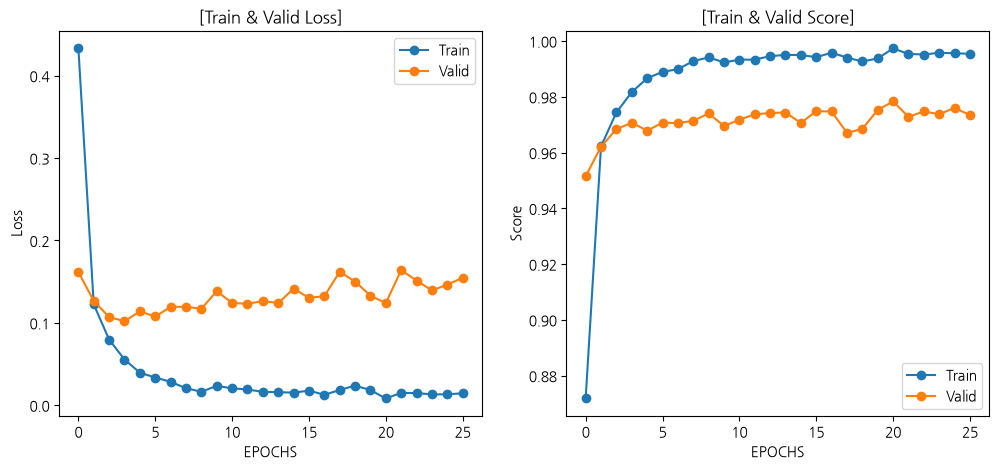

Valid Score 최고 지점 : EPOCH-0020  SCORE :0.9783553  LOSS :0.1240432


In [10]:
## ======================================================
## [2] 학습 과정 로그 기반 시각화
## ======================================================
fig, axes = plt.subplots(1, 2, figsize=(12,5))

for ax, title, epochList in zip(axes, ['Loss', 'Score'], [lossEpoch, scoreEpoch]):
    ax.plot(epochList['Train'], label='Train', marker='o')
    ax.plot(epochList['Valid'], label='Valid', marker='o')
    ax.set_title(f"[Train & Valid {title}]")
    ax.set_xlabel("EPOCHS")
    ax.set_ylabel(title)
    ax.legend()
plt.show()

## Valid Loss가 가장 낮은(=가장 좋은) 에포크 확인
best_epo = scoreEpoch['Valid'].index(max(scoreEpoch['Valid']))
print(f"Valid Score 최고 지점 : EPOCH-{best_epo:04}  SCORE :{scoreEpoch['Valid'][best_epo]:.7f}  LOSS :{lossEpoch['Valid'][best_epo]:.7f}")


In [11]:
## ======================================================
## [3] 최종 테스트셋(test.csv) 평가
## - 학습/검증에 전혀 사용되지 않은 홀드아웃 데이터로 최종 일반화 성능 확인
## ======================================================
test_loss, test_acc = evaluating(model, testDL, lossFN, len(feature_test), DIVICE)
print(f"[TEST] LOSS :{test_loss:.7f}  ACC :{test_acc:.7f}")


[TEST] LOSS :0.1121150  ACC :0.9772000
